In [1]:
import torch
import os
from utilities import *
device = torch.device('cpu')
print(device)

cpu


In [65]:
# Parameters

ranges = [-1, 1]
n_test = 1000
steps = 1200
grids = [3, 5, 10, 20, 50, 100]
k=3
lr=1
seed = 0
target_r2 = 0.95
increment = 100
dimensions = [100, 50, 20, 10, 5]

In [70]:
def find_N_binary(d, data, kan_type, seed=seed, target_r2=target_r2, min_samples=10, tolerance=10):

    dataset_path = os.path.join("datasets", f"seed {seed}", f"{data}_dataset_dim{d}_seed{seed}.pt")
    dataset = torch.load(dataset_path, map_location=device)

    total = dataset['train_input'].shape[0]
    low = min_samples
    high = total
    best = None
    last_result = None

    while low <= high:
        if (high - low) <= tolerance:
            break
        
        mid = (low + high) // 2
        if mid < min_samples:
            mid = min_samples

        sliced_dataset = {
            'train_input': dataset['train_input'][:mid],
            'train_label': dataset['train_label'][:mid],
            'test_input': dataset['test_input'],
            'test_label': dataset['test_label']
        }

        width = [d, 1, 1]
        if kan_type == "static":
            result = train_kan(dataset=sliced_dataset, width=width, k=k, lr=lr, steps=steps, seed=seed, grids=grids, static=True, target_r2=target_r2)
        elif kan_type == "dynamic":
            result = train_kan(dataset=sliced_dataset, width=width, k=k, lr=lr, steps=steps, seed=seed, grids=grids, static=False, target_r2=target_r2)
        else:
            raise ValueError(f"Invalid kan_type: {kan_type}")

        last_result = result
        achieved = result['r2s'][-1]
        if achieved >= target_r2:
            best = mid
            high = mid - 1
        else:
            low = mid + 1

    output_dir = os.path.join("2-results", f"seed {seed}")
    os.makedirs(output_dir, exist_ok=True)

    if best is not None:
        interval = (min(low, high), max(low, high))
        torch.save({'interval': interval, 'last_result': last_result}, os.path.join(output_dir, f"{kan_type}_{data}_result_dim{d}_seed{seed}_interval.pt"))
        return interval, last_result
    else:
        torch.save({'interval': None, 'last_result': last_result}, os.path.join(output_dir, f"{kan_type}_{data}_result_dim{d}_seed{seed}_interval.pt"))
        return None, last_result

In [71]:
N_results_static = {}
N_results_dynamic = {}

for data in ['A', 'B', 'C']:
    N_results_static[data] = {}
    N_results_dynamic[data] = {}
    for d in dimensions:
        print(f"Searching N for data={data}, dim={d} (static)")
        N_static, res_static = find_N_binary(d, data, 'static')
        N_results_static[data][d] = {'N': N_static, 'result': res_static}

        print(f"Searching N for data={data}, dim={d} (dynamic)")
        N_dyn, res_dyn = find_N_binary(d, data, 'dynamic')
        N_results_dynamic[data][d] = {'N': N_dyn, 'result': res_dyn}

Searching N for data=A, dim=100 (static)
Training with grid G = 3 on samples 0 to 505
Target R2 of 0.95 reached at step 13. N=505
Training with grid G = 3 on samples 0 to 257
Training with grid G = 3 on samples 0 to 381
Training with grid G = 3 on samples 0 to 443


KeyboardInterrupt: 

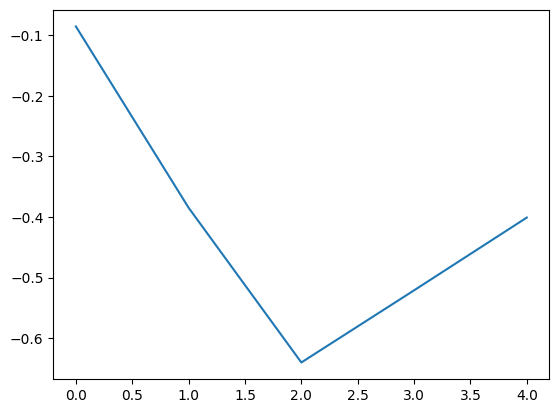

In [55]:
plt.plot(N_results_dynamic['A'][100]['result']['r2s'])

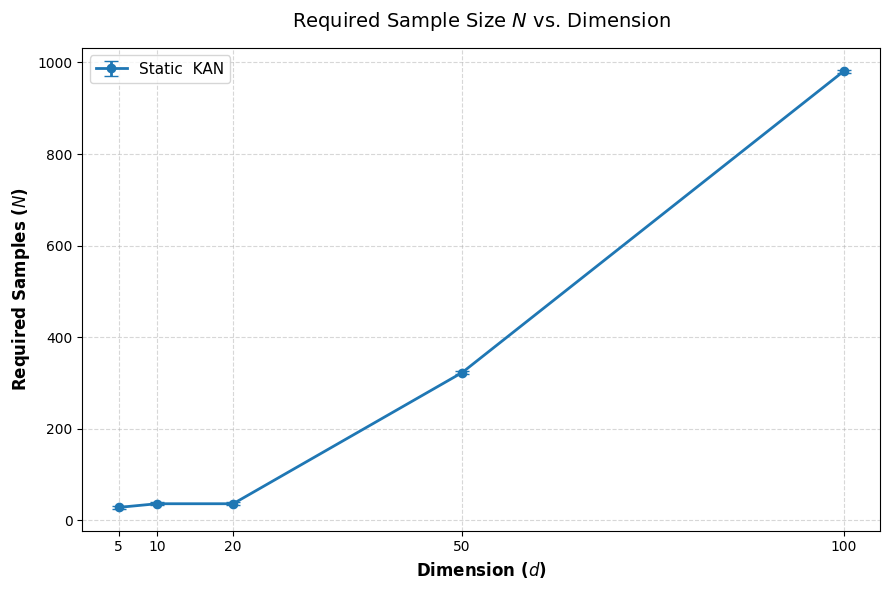

In [56]:
import matplotlib.pyplot as plt

plot_dimensions = []
required_N = []
error_lower = []
error_upper = []

for d in dimensions:
    result = N_results_dynamic['A'][d]['N']
    
    plot_dimensions.append(d)
    
    if isinstance(result, tuple):
        low, high = result
        mid_point = (low + high) / 2
        required_N.append(mid_point)
        error_lower.append(mid_point - low)
        error_upper.append(high - mid_point)
    else:
        required_N.append(result)
        error_lower.append(0)
        error_upper.append(0)

y_errors = [error_lower, error_upper]

# 3. Create the plot
plt.figure(figsize=(9, 6))

plt.errorbar(
    plot_dimensions, 
    required_N, 
    yerr=y_errors, 
    fmt='-o',          # Line style '-' with circle markers 'o'
    capsize=5,         # Caps on the ends of error bars
    color='#1f77b4',   # Clean blue color
    linewidth=2, 
    markersize=6, 
    label=f"{"static ".capitalize()} KAN"
)

# 4. Customize labels and styling
plt.xlabel("Dimension ($d$)", fontsize=12, fontweight='bold')
plt.ylabel("Required Samples ($N$)", fontsize=12, fontweight='bold')
plt.title(f"Required Sample Size $N$ vs. Dimension", fontsize=14, pad=15)

plt.xticks(dimensions)  # Ensure all evaluated dimensions show up on the x-axis
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# Display the plot
plt.tight_layout()
plt.show()

In [26]:
print(N_results_static['A'][5]['N'])

32


In [14]:
print(N_results_static['C'].keys())

dict_keys([300])


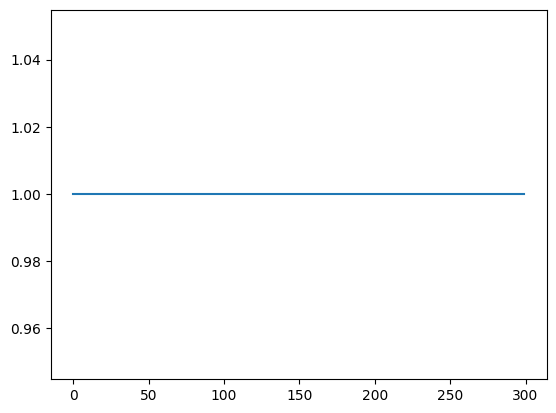

In [31]:
plt.plot(static_kan_A['r2s'][600:900])

In [4]:
static_kan_A = train_kan(width=width, dataset=dataset_A, steps=steps, grids=grids, lr=lr, k=k, device=device, static=True, seed=seed, increment=increment, target_r2=target_r2)

Training with grid G = 3 on samples 0 to 100
Training with grid G = 3 on samples 0 to 200
Training with grid G = 3 on samples 0 to 300
Training with grid G = 3 on samples 0 to 400
Training with grid G = 3 on samples 0 to 500
Training with grid G = 3 on samples 0 to 600
Training with grid G = 3 on samples 0 to 700
Training with grid G = 3 on samples 0 to 800
Training with grid G = 3 on samples 0 to 900
Training with grid G = 3 on samples 0 to 1000


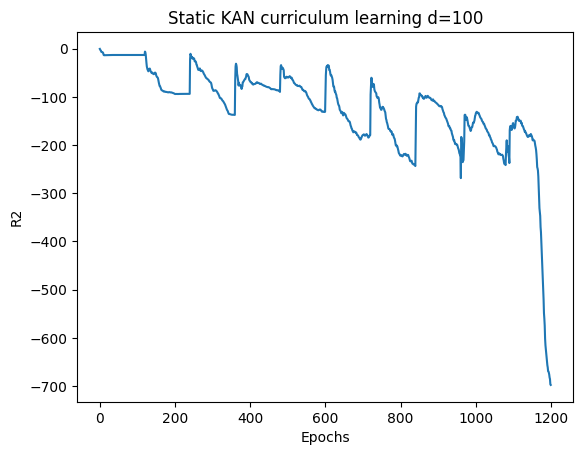

In [8]:
import matplotlib.pyplot as plt
plt.plot(static_kan_A['r2s'])
plt.title("Static KAN curriculum learning d=100")
plt.xlabel("Epochs")
plt.ylabel("R2")
plt.show()